In [1]:
import os

# Expose all logical CPU cores as JAX virtual devices for batch-level parallelism.
# Must be set *before* JAX initialises (i.e. before the first `import jax`).
os.environ.setdefault(
    "XLA_FLAGS",
    f"--xla_force_host_platform_device_count={os.cpu_count()}",
)

# ... rest of your imports

'--xla_force_host_platform_device_count=8'

In [2]:
import jax
import jax.numpy as jnp
import torch

from tensordev.sss import FSSK
from tensordev.kernel.fssk import FSSKSigKernel, fssk_sigkernel
from tensordev.kernel.sig import SigKernel as SigKernelMine

from sigkernel import SigKernel as SigSalvi
from sigkernel import  LinearKernel
salvi = SigSalvi(LinearKernel(), dyadic_order=0, _naive_solver=False)

def salvi_kernel(x, y):
    return jnp.array(salvi.compute_kernel(torch.tensor(x), torch.tensor(y)))

def salvi_gram(x, y):
    return jnp.array(salvi.compute_Gram(torch.tensor(x), torch.tensor(y)))

jax.config.update("jax_enable_x64", True)

In [3]:
# Shared toy data: integrated OU paths
# - dimension d = 20
# - 100 time steps
# - 64 samples in each batch

key = jax.random.PRNGKey(8998)
key_ = jax.random.PRNGKey(898098)

batch_size = 64
d = 20
n_x = 25
n_y = 25

t_x = jnp.linspace(0.0, 1.0, n_x)
t_y = jnp.linspace(0.0, 1.0, n_y)

dt_x = float(t_x[1] - t_x[0])
dt_y = float(t_y[1] - t_y[0])

from tensordev.util.random_paths import random_trigonometric_polynomial_paths

key_x, key_y = jax.random.split(key)
X = random_trigonometric_polynomial_paths(key, batch=batch_size, steps=n_x, dim=d, horizon=1.0)
Y = random_trigonometric_polynomial_paths(key_, batch=batch_size, steps=n_x, dim=d, horizon=1.0)

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("dt_x:", dt_x, "dt_y:", dt_y)


X shape: (64, 26, 20)
Y shape: (64, 26, 20)
dt_x: 0.041666666666666664 dt_y: 0.041666666666666664


In [4]:
lam = 0.0

ker_exp_scalar = FSSK.from_matrix(
    Lambda=jnp.array([[lam]]),
    A=jnp.eye(d)[None, :, :],
    b=jnp.array([[1.0]]),
)

sigker_exp_scalar = FSSKSigKernel(
    kernel=ker_exp_scalar,
    dt_x=dt_x,
    dt_y=dt_y,
    backend="scan",
)

k_batch_1 = sigker_exp_scalar.compute_kernel(X, Y)
G_1 = sigker_exp_scalar.compute_Gram(X, Y)
eta_grid_1 = fssk_sigkernel(
    X[:1],
    Y[:1],
    kernel=ker_exp_scalar,
    dt_x=dt_x,
    dt_y=dt_y,
    evaluate="grid",
    dyadic_order=5
)

print("batchwise k(X_i, Y_i):", k_batch_1)
print("Gram shape:", G_1.shape)
print("terminal value for first pair:", eta_grid_1[0, -1, -1])

# Zero-lambda comparison against the classical signature kernel.
ker_exp_zero = FSSK.from_matrix(
    Lambda=jnp.array([[0.0]]),
    A=jnp.eye(d)[None, :, :],
    b=jnp.array([[1.0]]),
)

sigker_fssk_zero = FSSKSigKernel(
    kernel=ker_exp_zero,
    dt_x=dt_x,
    dt_y=dt_y,
    backend="scan",
    dyadic_order=0,
    scheme="heun"
)

sigker_classical = SigKernelMine(dyadic_order=0)

k_fssk_zero = sigker_fssk_zero.compute_kernel(X[:1], Y[:1])
k_sig_zero = sigker_classical(X[:1], Y[:1])

print("FSSK with lambda=0:", k_fssk_zero)
print("Classical SigKernel:", k_sig_zero)
print("absolute difference:", jnp.abs(k_fssk_zero - k_sig_zero))


batchwise k(X_i, Y_i): [ 1.82337370e+00  1.04307033e+00  1.08871055e+00 -2.46496747e+00
  7.22208584e-01  7.94285031e+00  2.71714936e+00  1.41499159e+00
 -2.06058548e+00  5.73850138e+00  9.87761192e+00  9.03692939e-01
  1.60110728e+00  2.81376900e+01  2.07175581e+00  2.18342178e+00
  4.40487794e+00  7.30829893e-01  9.36321110e-01  5.56366415e-01
  1.22335545e+00 -2.23707118e-01 -9.93894107e-01 -1.19679298e+00
 -3.38175799e+00 -1.95887844e+00  4.07105782e-02  5.93343552e+01
 -4.28354414e-01 -3.06334867e+00  1.02772182e-02  6.69945230e-01
  1.35412264e+00  2.02687615e+00  1.34429663e+00  3.88247449e+00
  2.59134751e+00  2.25816855e+01  3.09334493e+00  1.15941947e-01
  1.99744992e+00  1.01546058e+00  9.59529303e-01  5.31337065e+00
  3.27170393e+00 -3.20183610e-01  9.60754994e-01  1.42969612e+00
  4.98733454e+00  1.11683718e+00  1.00541418e+01  3.28577787e-01
  3.20961282e-01 -1.84520399e-02  5.60343876e-01  5.12664718e+00
  6.78911919e+00  2.98199949e-01  6.04915833e-01  8.80940131e+00
 -

In [5]:
# Deterministic single-path example translated from the provided Torch code.
# We match the Torch grids exactly: Ns and Nt are numbers of intervals,
# so the actual number of grid points is Ns + 1 and Nt + 1.

dtype = jnp.float64
Ns = 100
Nt = 100
d_det = d

s_grid = jnp.linspace(0.0, 1.0, Ns + 1, dtype=dtype)
t_grid = jnp.linspace(0.0, 1.0, Nt + 1, dtype=dtype)
dt_s = float(s_grid[1] - s_grid[0])
dt_t = float(t_grid[1] - t_grid[0])

idx = jnp.arange(1, d_det + 1, dtype=dtype)

freq_x_1 = 0.6 + 0.03 * idx
freq_x_2 = 1.0 + 0.02 * idx
phase_x = 0.11 * idx

freq_w_1 = 0.8 + 0.025 * idx
freq_w_2 = 1.1 + 0.015 * idx
phase_w = -0.09 * idx

x = (
    0.35 * jnp.sin(2.0 * jnp.pi * s_grid[:, None] * freq_x_1[None, :] + phase_x[None, :])
    + 0.25 * jnp.cos(2.0 * jnp.pi * s_grid[:, None] * freq_x_2[None, :] - 0.5 * phase_x[None, :])
    + 0.08 * (idx / d_det)[None, :] * s_grid[:, None]
    + 0.04 * (1.0 - idx / d_det)[None, :] * s_grid[:, None] ** 2
)

w = (
    0.30 * jnp.sin(2.0 * jnp.pi * t_grid[:, None] * freq_w_1[None, :] + phase_w[None, :])
    + 0.28 * jnp.cos(2.0 * jnp.pi * t_grid[:, None] * freq_w_2[None, :] - 0.3 * phase_w[None, :])
    + 0.07 * (idx / d_det)[None, :] * t_grid[:, None]
    + 0.05 * (1.0 - idx / d_det)[None, :] * t_grid[:, None] ** 2
)

# Add a batch axis so the public API matches the earlier examples.
X_det = x[None, ...]
Y_det = w[None, ...]

ker_diag_05_10 = FSSK.from_prony(
    A=jnp.eye(d_det, dtype=dtype)[None, :, :],
    real_rates=(0.0, 0.0),
    real_sizes=(1, 1),
    alpha=jnp.array([[0.5, 0.5]], dtype=dtype),
)

sigker_diag_05_10 = FSSKSigKernel(
    kernel=ker_diag_05_10,
    dt_x=dt_s,
    dt_y=dt_t,
    backend="scan",
)

k_det = sigker_diag_05_10.compute_kernel(X_det, Y_det)
eta_det = fssk_sigkernel(
    X_det,
    Y_det,
    kernel=ker_diag_05_10,
    dt_x=dt_s,
    dt_y=dt_t,
    backend="scan",
    evaluate="grid",
)


print("s_grid points:", s_grid.shape[0], "t_grid points:", t_grid.shape[0])
print("x shape:", x.shape)
print("w shape:", w.shape)
print("kernel value:", k_det)
print("terminal grid value:", eta_det[0, -1, -1])

salvi_kernel(X_det, Y_det)


s_grid points: 101 t_grid points: 101
x shape: (101, 20)
w shape: (101, 20)
kernel value: [8.0343562]
terminal grid value: 8.03435619621883


Array([8.0349564], dtype=float64)

In [6]:
def make_batch_from_base_path(base_path: jnp.ndarray, batch_size: int, grid: jnp.ndarray) -> jnp.ndarray:
    """
    JAX version of the provided Torch helper.

    base_path: (length, d)
    returns:   (batch, length, d)
    """
    length, d_loc = base_path.shape
    idx_loc = jnp.arange(1, d_loc + 1, dtype=base_path.dtype)
    k = jnp.arange(batch_size, dtype=base_path.dtype)

    a_batch = 0.010 * (k + 1.0) / batch_size                    # (batch,)
    b_batch = 0.008 * (k + 1.0) / batch_size                    # (batch,)

    freq1 = 0.5 + 0.03 * idx_loc[None, :] + 0.02 * k[:, None]   # (batch, d)
    freq2 = 0.9 + 0.02 * idx_loc[None, :] + 0.015 * k[:, None]  # (batch, d)
    phase = 0.07 * idx_loc[None, :] + 0.03 * k[:, None]         # (batch, d)

    g = grid[:, None, None]                                      # (length, 1, 1)
    freq1_b = freq1[None, :, :]                                  # (1, batch, d)
    freq2_b = freq2[None, :, :]                                  # (1, batch, d)
    phase_b = phase[None, :, :]                                  # (1, batch, d)
    a_b = a_batch[None, :, None]                                 # (1, batch, 1)
    b_b = b_batch[None, :, None]                                 # (1, batch, 1)

    perturb = (
        a_b * jnp.sin(2.0 * jnp.pi * g * freq1_b + phase_b)
        + b_b * jnp.cos(2.0 * jnp.pi * g * freq2_b - 0.5 * phase_b)
    )                                                             # (length, batch, d)

    return base_path[None, :, :] + jnp.swapaxes(perturb, 0, 1)   # (batch, length, d)


R = 2
d_loc = 20
m = d_loc
q = 1

Ns = 10
Nt = 10

dyadic_order = 0
backend = "scan"   # Torch 'solver_type = "naive"' mapped to the scan backend
scheme = "heun"

lambda1 = 1.0
lambda2 = 1.0
a = -0.5
alpha1 = 0.5
alpha2 = 0.5

batch_X = 100
batch_Y = 100

Lambda = jnp.array(
    [
        [lambda1, -a],
        [a, lambda2],
    ],
    dtype=dtype,
)

# q = 1, m = d, A_1 = I_d
A = jnp.eye(d_loc, dtype=dtype)[None, :, :]                      # (1, d, d)

# b shape (q, R) = (1, 2)
b = jnp.array([[alpha1, alpha2]], dtype=dtype)

X_batch = make_batch_from_base_path(x, batch_X, s_grid)
Y_batch = make_batch_from_base_path(w, batch_Y, t_grid)

ker_coupled = FSSK.from_matrix(
    Lambda=Lambda,
    A=A,
    b=b,
)
sigker_coupled = FSSKSigKernel(
    kernel=ker_coupled,
    dt_x=float(s_grid[1] - s_grid[0]),
    dt_y=float(t_grid[1] - t_grid[0]),
    backend=backend,
    dyadic_order=dyadic_order,
    scheme=scheme,
    precompute_propagators=True,
    num_devices=8
)

In [7]:
G_coupled = sigker_coupled.compute_Gram(X_batch, Y_batch)
G_coupled

Array([[4.03779299, 4.03436113, 4.03096857, ..., 3.55035401, 3.55116534,
        3.56058437],
       [4.04014845, 4.03671407, 4.03331893, ..., 3.55224337, 3.55305936,
        3.56249044],
       [4.04280971, 4.03937245, 4.0359745 , ..., 3.55443578, 3.55525489,
        3.56469654],
       ...,
       [4.12934837, 4.12574091, 4.12225041, ..., 3.67105707, 3.67055784,
        3.67822194],
       [4.14161272, 4.13798609, 4.13448273, ..., 3.68563932, 3.68503968,
        3.69256664],
       [4.1526026 , 4.14895902, 4.14544407, ..., 3.69864883, 3.69796135,
        3.70536843]], dtype=float64)

In [8]:
''# Same batched deterministic setup, but constructed through the Jordan interface.

mu = 0.5 * (lambda1 + lambda2)
omega = jnp.sqrt(a**2 - (0.5 * (lambda1 - lambda2))**2)

print("mu:", mu)
print("omega:", omega)

ker_jordan = FSSK.from_jordan(
    A=A,
    b=jnp.array([[0.5, 0.5]], dtype=dtype),
    osc_decays=(mu,),
    osc_freqs=(omega,),
    osc_sizes=(1,),
)

sigker_jordan = FSSKSigKernel(
    kernel=ker_jordan,
    dt_x=float(s_grid[1] - s_grid[0]),
    dt_y=float(t_grid[1] - t_grid[0]),
    backend=backend,
    dyadic_order=dyadic_order,
    scheme=scheme,
    precompute_propagators=False
)

mu: 1.0
omega: 0.5


In [9]:
G_jordan = sigker_jordan.compute_Gram(X_batch, Y_batch)
G_jordan

Array([[4.03779299, 4.03436113, 4.03096857, ..., 3.55035401, 3.55116534,
        3.56058437],
       [4.04014845, 4.03671407, 4.03331893, ..., 3.55224337, 3.55305936,
        3.56249044],
       [4.04280971, 4.03937245, 4.0359745 , ..., 3.55443578, 3.55525489,
        3.56469654],
       ...,
       [4.12934837, 4.12574091, 4.12225041, ..., 3.67105707, 3.67055784,
        3.67822194],
       [4.14161272, 4.13798609, 4.13448273, ..., 3.68563932, 3.68503968,
        3.69256664],
       [4.1526026 , 4.14895902, 4.14544407, ..., 3.69864883, 3.69796135,
        3.70536843]], dtype=float64)

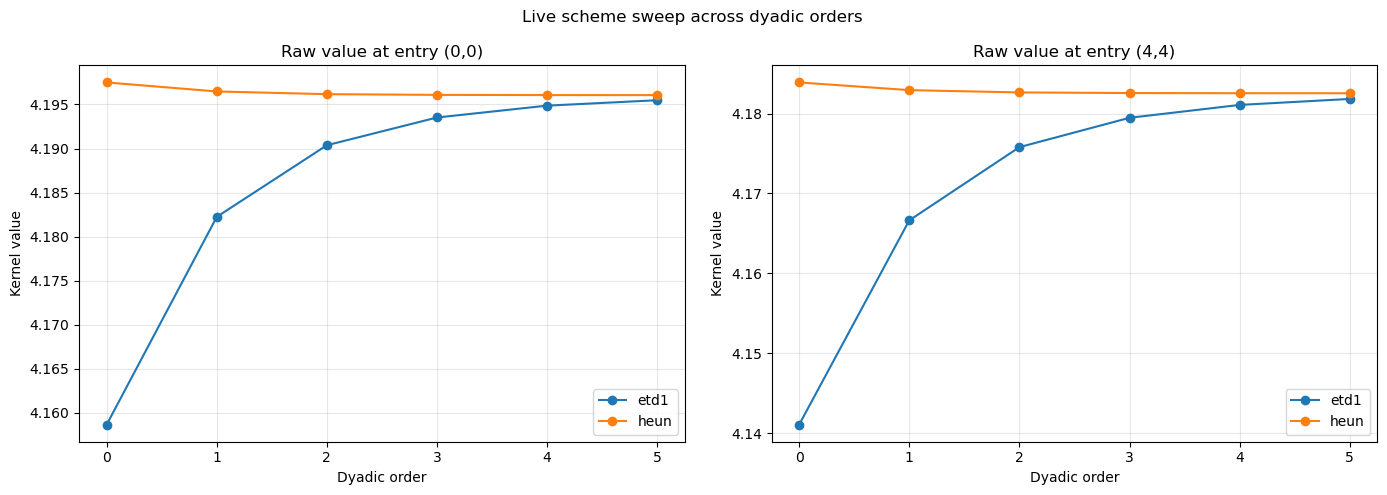

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

import jax
import jax.numpy as jnp

from tensordev.kernel.fssk import FSSKSigKernel
from tensordev.sss.kernel import FSSK


def make_batch_from_base_path(base_path: jnp.ndarray, batch_size: int, grid: jnp.ndarray) -> jnp.ndarray:
    """
    base_path: (length, d)
    returns:   (batch, length, d)
    """
    length, d_loc = base_path.shape
    idx_loc = jnp.arange(1, d_loc + 1, dtype=base_path.dtype)
    k = jnp.arange(batch_size, dtype=base_path.dtype)

    a_batch = 0.010 * (k + 1.0) / batch_size
    b_batch = 0.008 * (k + 1.0) / batch_size

    freq1 = 0.5 + 0.03 * idx_loc[None, :] + 0.02 * k[:, None]
    freq2 = 0.9 + 0.02 * idx_loc[None, :] + 0.015 * k[:, None]
    phase = 0.07 * idx_loc[None, :] + 0.03 * k[:, None]

    g = grid[:, None, None]
    freq1_b = freq1[None, :, :]
    freq2_b = freq2[None, :, :]
    phase_b = phase[None, :, :]
    a_b = a_batch[None, :, None]
    b_b = b_batch[None, :, None]

    perturb = (
        a_b * jnp.sin(2.0 * jnp.pi * g * freq1_b + phase_b)
        + b_b * jnp.cos(2.0 * jnp.pi * g * freq2_b - 0.5 * phase_b)
    )

    return base_path[None, :, :] + jnp.swapaxes(perturb, 0, 1)


# ------------------------------------------------------------
# Problem setup
# ------------------------------------------------------------

print("x shape    :", x.shape)
print("w shape    :", w.shape)
print("s_grid shape:", s_grid.shape)
print("t_grid shape:", t_grid.shape)
print("dtype      :", dtype)

R = 2
d_loc = 20
q = 1

backend = "wavefront"
precompute_propagators = True

lambda1 = .5
lambda2 = 1.5
a = -0.5
alpha1 = 0.5
alpha2 = 0.5

batch_X = 5
batch_Y = 5

Lambda = jnp.array(
    [
        [lambda1, -a],
        [a, lambda2],
    ],
    dtype=dtype,
)

A = jnp.eye(d_loc, dtype=dtype)[None, :, :]
b = jnp.array([[alpha1, alpha2]], dtype=dtype)

X_batch = make_batch_from_base_path(x, batch_X, s_grid)
Y_batch = make_batch_from_base_path(w, batch_Y, t_grid)

ker_coupled = FSSK.from_matrix(
    Lambda=Lambda,
    A=A,
    b=b,
)

dt_x0 = float(s_grid[1] - s_grid[0])
dt_y0 = float(t_grid[1] - t_grid[0])

print("X_batch shape:", X_batch.shape)
print("Y_batch shape:", Y_batch.shape)
print("dt_x0:", dt_x0)
print("dt_y0:", dt_y0)


SCHEMES = [
    "etd1",
    "heun",
]

RICHARDSON_ORDER = {
    "etd1": 1,
    "heun": 2,
}


# ------------------------------------------------------------
# Kernel evaluation helpers
# ------------------------------------------------------------

def compute_gram_for_scheme(
    scheme: str,
    dyadic_order: int,
    *,
    backend: str = backend,
    precompute_propagators: bool = precompute_propagators,
):
    sigker_coupled = FSSKSigKernel(
        kernel=ker_coupled,
        dt_x=dt_x0,
        dt_y=dt_y0,
        backend=backend,
        dyadic_order=dyadic_order,
        scheme=scheme,
        precompute_propagators=precompute_propagators,
    )
    G = sigker_coupled.compute_Gram(X_batch, Y_batch, sym=False)
    return np.asarray(jax.device_get(G))


def dyadic_richardson(vals, order):
    """
    vals: shape (L, n, m)
    order: assumed asymptotic order p
    """
    fac = 2.0 ** order
    R1 = (fac * vals[1:] - vals[:-1]) / (fac - 1.0)
    R2 = (fac * R1[1:] - R1[:-1]) / (fac - 1.0)
    return R1, R2


def build_extrapolated_results(raw_results, richardson_orders):
    out = {}
    for scheme, vals in raw_results.items():
        arr = np.stack(vals, axis=0)
        p = richardson_orders[scheme]
        R1, R2 = dyadic_richardson(arr, p)
        out[scheme] = {
            "raw": arr,
            "R1": R1,
            "R2": R2,
            "p": p,
        }
    return out


# ------------------------------------------------------------
# Notebook-safe live sweep
# ------------------------------------------------------------

def run_scheme_sweep_live_notebook(
    schemes=SCHEMES,
    max_dyadic_order=7,
    entries=((0, 0), (4, 4)),
    sleep_time=0.05,
):
    """
    Notebook-safe live sweep:
    - computes all schemes for dyadic orders 0,...,max_dyadic_order
    - re-renders the figure in-place inside the notebook output cell
    """
    n_entries = len(entries)
    fig, axes = plt.subplots(1, n_entries, figsize=(7 * n_entries, 5))
    if n_entries == 1:
        axes = [axes]

    line_handles = {}
    raw_results = {scheme: [] for scheme in schemes}

    for ax, (i, j) in zip(axes, entries):
        ax.set_title(f"Raw value at entry ({i},{j})")
        ax.set_xlabel("Dyadic order")
        ax.set_ylabel("Kernel value")
        ax.grid(True, alpha=0.3)

        for scheme in schemes:
            (line,) = ax.plot([], [], marker="o", label=scheme)
            line_handles[(scheme, i, j)] = line

        ax.legend()

    fig.suptitle("Live scheme sweep across dyadic orders")
    plt.tight_layout()

    for ell in range(max_dyadic_order + 1):
        log_lines = [f"=== dyadic_order = {ell} ==="]

        for scheme in schemes:
            t0 = time.time()
            G = compute_gram_for_scheme(scheme, ell)
            raw_results[scheme].append(G)
            elapsed = time.time() - t0
            log_lines.append(f"{scheme:>10s}: {elapsed:7.3f}s")

            xs = np.arange(len(raw_results[scheme]))
            for (i, j) in entries:
                ys = np.array([M[i, j] for M in raw_results[scheme]])
                line_handles[(scheme, i, j)].set_data(xs, ys)

        for ax in axes:
            ax.relim()
            ax.autoscale_view()

        clear_output(wait=True)
        print("\n".join(log_lines))
        display(fig)
        time.sleep(sleep_time)

    plt.close(fig)
    return raw_results


# ------------------------------------------------------------
# Error plot against heun Richardson(6,7) target
# ------------------------------------------------------------

def plot_avg_abs_error_to_target(raw_results, target, schemes=SCHEMES, title_suffix=""):
    fig, ax = plt.subplots(figsize=(10, 6))

    summary = {}

    for scheme in schemes:
        vals = np.stack(raw_results[scheme], axis=0)   # (L, n, m)
        errs = np.mean(np.abs(vals - target[None, :, :]), axis=(1, 2))
        levels = np.arange(vals.shape[0])

        summary[scheme] = errs
        ax.semilogy(levels, errs, marker="o", label=scheme)

    ax.set_xlabel("Dyadic order")
    ax.set_ylabel("Mean absolute error over Gram matrix")
    ax.set_title(f"Average absolute error to heun Richardson target{title_suffix}")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    return summary


# ------------------------------------------------------------
# Run sweep up to dyadic 6
# ------------------------------------------------------------

raw_results = run_scheme_sweep_live_notebook(
    schemes=SCHEMES,
    max_dyadic_oder=6,
    entries=((0, 0), (4, 4)),
    sleep_time=0.1,
)

results = build_extrapolated_results(raw_results, RICHARDSON_ORDER)

# ------------------------------------------------------------
# Target = heun Richardson extrapolation from dyadic 6 and 7
# ------------------------------------------------------------

# Since raw levels are 0..7, R1[-1] is the Richardson extrapolation using levels 5 and 6.
target_heun_56 = results["heun"]["R1"][-1]

print("Target shape:", target_heun_56.shape)
print("heun Richardson target from dyadic 6/7:")
print(target_heun_56)

# ------------------------------------------------------------
# Plot average absolute error in log scale
# ------------------------------------------------------------

error_summary = plot_avg_abs_error_to_target(
    raw_results,
    target_heun_56,
    schemes=SCHEMES,
    title_suffix=" (target = heun R1 from levels 6 and 7)",
)

# Optional: print the numeric errors
print("\nMean absolute errors by scheme and dyadic order:")
for scheme, errs in error_summary.items():
    print(f"\n{scheme}:")
    for ell, err in enumerate(errs):
        print(f"  level {ell}: {err:.6e}")